#Project Scope

Dataset: [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews/data) (1999–2012). After deduplication and noise removal, the corpus consists of 393,645 unique reviews from 256,059 users across 67,488 products.

Course Techniques:  

*   Text Mining: Frequency analysis of unigrams and bi-grams.
*   Graph Mining: Identifying user product relationships and node degree (User Segmentation).
* Anomaly Detection: Identifying helpfulness inconsistencies and rating sentiment disconnects.

External Techniques:

* Topic Modeling (LDA): To uncover hidden themes within review text.
* Transformer based Embeddings: For deeper semantic context beyond keyword matching.
* Sequential Pattern Mining: To track the evolution of user behavior over time.


Key EDA Findings
* 1-star reviews are significantly longer on average than 5-star reviews, indicating that dissatisfied customers provide more descriptive evidence for their claims.

* There is a strong positive correlation between word count and the Helpfulness Ratio, suggesting the community views long form content as more authoritative.

* The user base follows a power law distribution; a small group of Power Users (those with 5+ reviews) act as the primary hubs connecting disparate product categories in the network graph.

* The dataset captures a decade of evolution, showing distinct burst of activity that allow for the study of how consumer vocabulary matures over time.

#Research Question Definition

These research questions have been created based on the EDA performed in checkpoint1.

## RQ1

RQ 1: To what extent can the statistical disconnect between a review's literal text sentiment and its numerical score be used to identify potential anomalies or shill reviews?

* Motivation: The goal is to identify shill reviews or automated bot activity where the numerical rating is used to manipulate product rankings, while the text remains generic or inconsistent. By measuring the disconnect between words and scores, the study aims to improve data integrity in the Amazon marketplace.

* Non-triviality: Identifying these anomalies is difficult because it requires comparing two different scales: lexical sentiment (unstructured text) and ordinal ratings (1–5). A simple filter cannot detect the subtle statistical mismatch between the intensity of a review's words and the star rating provided.

* Feasibility: Initial EDA confirms a strong textual signal, with distinct marker phrases (for ex :  "waste money" vs. "highly recommend") appearing in different rating categories. This confirms the vocabulary is descriptive enough for lexicon-based tools like VADER to yield meaningful polarity scores.

* Risks: High variance language, such as sarcasm or mixed reviews (where a user likes the product but hates the shipping), might be flagged as false positives.

* Data Mining Task: Anomaly Detection / Text Mining.

* Course Algorithms: Text Mining (n-gram analysis), Anomaly Detection (residual outliers with z-score/Isolation Forest)

* External Algorithms: VADER sentiment scoring.

* Relevant Algorithms: VADER (Valence Aware Dictionary and sEntiment Reasoner) for sentiment lexicon analysis, combined with Isolation Forest or Z-Score analysis to flag outliers where the sentiment score and review score are inversely related.

* Evaluation Criteria: Precision and Recall (via a manually sampled audit of the top 100 outliers) and Cohen’s Kappa Coefficient to measure the level of disagreement between the human assigned score and the mined sentiment.

* Baselines: Simple keyword counting (for ex: frequency of good vs. bad words) as a predictor for the star rating.

* Approach : The plan is to assign a numerical sentiment score to the text of every review using the VADER lexicon. This provides a polarity score between -1 (extremely negative) and 1 (extremely positive). This score will be compared against the user-assigned star rating (1–5). By normalizing these two scales, a Residual Score can be calculated for every entry. An Isolation Forest algorithm will then be used to identify the statistical outliers specifically, reviews where the sentiment of the words is radically different from the rating given. These outliers will be flagged as potential shill reviews or anomalies for manual audit.



## RQ 2

RQ 2: Does a user's Authority Score in a bipartite user product graph act as a more reliable predictor of review helpfulness than simple review volume?

* Motivation: This question investigates whether a user's structural position in a review network. Their authority is a more accurate predictor of their influence than the raw number of reviews they have written. This helps in identifying high-quality reviewers whose feedback the community should prioritize.


* Non-triviality: Authority is a recursive property; influential users review vetted products, and vetted products are reviewed by influential users. This complexity requires modeling the data as a bipartite graph rather than treating users as isolated data points.


* Feasibility: EDA confirms that the user base follows a Power Law distribution, creating a hub and spoke structure. With a small percentage of power users responsible for most edges, the graph is sufficiently dense for authority-based algorithms to converge.

* Risks: Processing a graph with over 250,000 users and 60,000 products may lead to high memory consumption or computational latency.

* Data Mining Task: Graph Mining.

* Course Algorithms: Graph Mining (bipartite graph, node degree analysis).

* External Algorithms: HITS / Modified PageRank with helpfulness weighting

* Relevant Algorithms: HITS to identify Hubs  and Authorities (vetted products), or a Modified PageRank algorithm where the jump probability is weighted by a user’s Helpfulness Ratio.

* Evaluation Criteria: Spearman’s Rank Correlation between a node's Authority Score and its historical Helpfulness Ratio, as well as Node Degree Distribution analysis to confirm the presence of a power-law relationship in community influence.

* Baselines: Simple Review Volume (the total count of reviews per user) used as a predictor for helpfulness.

* Approach : The implementation involves constructing a bipartite graph where one set of nodes represents unique UserIds and the other represents ProductIds. An edge is created whenever a user reviews a product. The HITS (Hubs and Authorities) algorithm will be applied to this network. In this context, a Hub is a user who reviews many high-quality products, and an Authority is a product vetted by many reliable users. To make the model more robust, the jump probability in the graph will be weighted by the user’s historical Helpfulness Ratio, effectively giving more voting power to reviewers the community already trusts.

## RQ 3

RQ 3:  What latent themes (for example :  taste, shipping, packaging, price) are the primary drivers of helpfulness votes in the Power User segment compared to the Amateur segment?

* Motivation: The project aims to uncover the specific themes (such as taste, price, or packaging) that drive community trust and helpfulness votes. Understanding these drivers allows for better categorization of reviews based on consumer needs.

* Non-triviality: Uncovering hidden themes across 393,645 reviews is an unsupervised learning task. It requires the machine to discover clusters of co-occurring words that represent broad concepts without pre-defined labels.

* Feasibility: Preliminary EDA shows that helpful reviews are consistently longer and more detailed. This depth provides enough lexical data for Latent Dirichlet Allocation (LDA) to extract distinct, non-overlapping themes.

* Risks: Selecting an improper number of topics (k) could result in themes that are too broad to be useful or too specific to be generalized.

* Data Mining Task: Topic Modeling (external).

* Course Algorithms: Text Mining preprocessing (tokenization, lemmatization).

* External Algorithms: Topic Modeling (LDA), optional Transformer-based embeddings.

* Relevant Algorithm: Latent Dirichlet Allocation (LDA) to discover the hidden thematic structure in the 393,645 reviews. This moves beyond simple keywords to identify clusters of co-occurring words that represent broader concepts.

* Evaluation Criteria: Topic Coherence score to measure how well the topics are defined and Perplexity to evaluate how well the model predicts a held-out set of reviews.

* Baselines: Using the most frequent bi-grams from the EDA to manually categorize review topics.

* Approach : The goal is to move beyond looking at individual words and instead group reviews by their underlying themes using Latent Dirichlet Allocation (LDA). The text will undergo lemmatization (reducing words to their root form) and the removal of domain specific stop words . The LDA model will then identify k number of topics across the 393,645 reviews. Once these topics are identified, the project will compare the Topic Distribution of highly voted helpful reviews against those with zero helpfulness votes to see which themes (for example Ingredient Quality vs. Shipping Speed) drive community engagement.



## All Research Questions: Method Mapping

| Research Question | Technique |
|---|---|
| **RQ1:** To what extent can the statistical disconnect between a review’s literal text sentiment and its numerical score identify potential anomalies or shill reviews? | **Course:** Text Mining (n-gram analysis), Anomaly Detection (residual outliers with z-score/Isolation Forest). **External:** VADER sentiment scoring. |
| **RQ2:** Does a user’s authority score in a bipartite user-product graph predict review helpfulness better than review volume? | **Course:** Graph Mining (bipartite graph, node degree analysis). **External:** HITS / Modified PageRank with helpfulness weighting. |
| **RQ3:** What latent themes are the primary drivers of helpfulness votes in Power Users compared to Amateur Users? | **Course:** Text Mining preprocessing (tokenization, lemmatization). **External:** Topic Modeling (LDA), optional Transformer-based embeddings. |

#Additional EDA related to RQs


In [15]:
#Code
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "/content/Reviews.csv.zip"

df = pd.read_csv(file_path)

#sort by ProductId to maintain a consistent first instance of a review
df_sorted = df.sort_values('ProductId', axis=0, ascending=True)

#drop duplicates where the User, ProfileName, and Text are identical.
df_cleaned = df_sorted.drop_duplicates(subset={"UserId","ProfileName","Text"}, keep='first', inplace=False)

# helpfulness sanity check
df_cleaned = df_cleaned[df_cleaned.HelpfulnessNumerator <= df_cleaned.HelpfulnessDenominator]

# date & time conversion
df_cleaned['DateTime'] = pd.to_datetime(df_cleaned['Time'], unit='s')
df_cleaned['Year'] = df_cleaned['DateTime'].dt.year
df_cleaned['Month'] = df_cleaned['DateTime'].dt.month

# text length analysis
df_cleaned['Text_Word_Count'] = df_cleaned['Text'].apply(lambda x: len(str(x).split()))

user_counts = df_cleaned.groupby('UserId')['Id'].count().reset_index()
user_counts.columns = ['UserId', 'ReviewCount']

def segment_user(count):
    if count <= 2:
        return 'Amateur Reviewer (1-2)'
    elif count <= 5:
        return 'Active Reviewer (3-5)'
    else:
        return 'Very Active Reviewer (5+)'

user_counts['User_Segment'] = user_counts['ReviewCount'].apply(segment_user)
df_cleaned = df_cleaned.merge(user_counts[['UserId', 'User_Segment']], on='UserId', how='left')

Above is the code taken from checkpoint 1 which just reads and performs basic cleaning before performing additional EDA Tasks

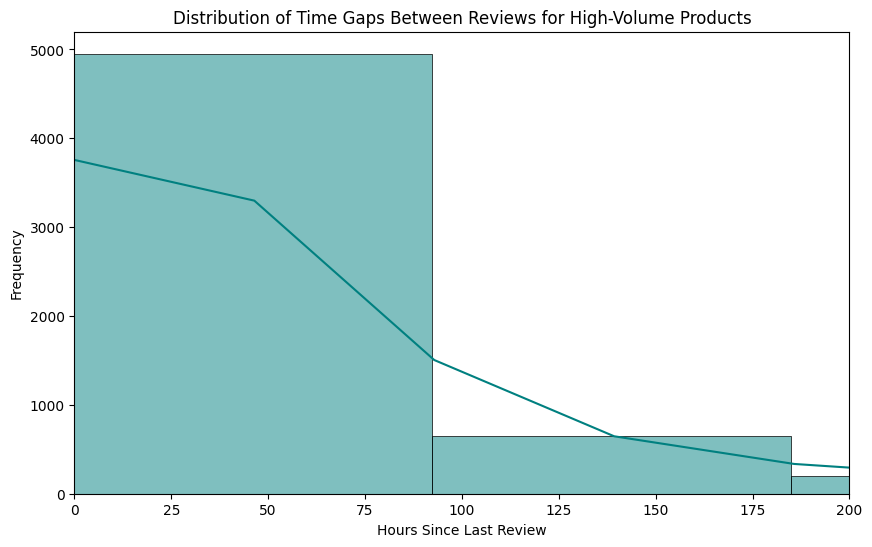

In [16]:
#Code

# Temporal Review Velocity (Burst Analysis). This identifies products that receive a sudden spike in reviews
top_products = df_cleaned['ProductId'].value_counts().nlargest(10).index
burst_df = df_cleaned[df_cleaned['ProductId'].isin(top_products)].copy()
burst_df = burst_df.sort_values(['ProductId', 'DateTime'])

# Calculate the time difference (in hours) between consecutive reviews for the same product
burst_df['Time_Diff_Hours'] = burst_df.groupby('ProductId')['DateTime'].diff().dt.total_seconds() / 3600

plt.figure(figsize=(10, 6))
sns.histplot(burst_df['Time_Diff_Hours'].dropna(), bins=100, kde=True, color='teal')
plt.title('Distribution of Time Gaps Between Reviews for High-Volume Products')
plt.xlabel('Hours Since Last Review')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.show()


The first step involved a Burst Analysis to measure the time intervals between consecutive reviews for the most popular products. The goal was to identify temporal anomalies that is sudden spikes in review volume that might suggest coordinated activity or shilling. The distribution of time gaps shows a massive concentration of reviews occurring within 0 to 25 hours of one another. This heavy tailed distribution confirms that high volume products do not receive feedback at a steady, linear pace. Instead, engagement is highly clustered. For the research into anomaly detection, this baseline is critical: any product that deviates from this curve with an even tighter, near zero hour gap across multiple 5-star ratings can be statistically flagged as a potential manipulation event.


/tmp/ipykernel_383/2431476361.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='User_Segment', y='Lexical_Diversity', data=df_cleaned, palette='Set2')


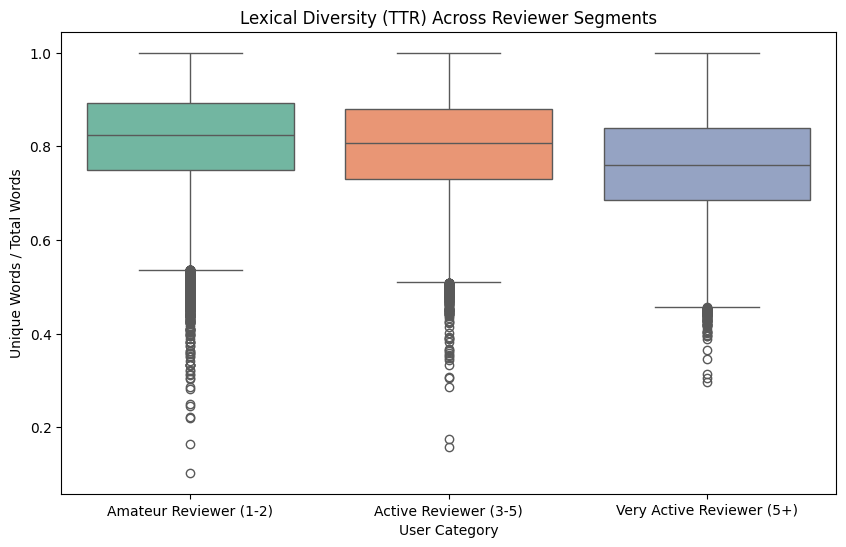

In [17]:
# Lexical Diversity per User Segment Type Token Ratio (TTR) measures vocabulary richness
def calculate_ttr(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df_cleaned['Lexical_Diversity'] = df_cleaned['Text'].apply(calculate_ttr)

plt.figure(figsize=(10, 6))
sns.boxplot(x='User_Segment', y='Lexical_Diversity', data=df_cleaned, palette='Set2')
plt.title('Lexical Diversity (TTR) Across Reviewer Segments')
plt.ylabel('Unique Words / Total Words')
plt.xlabel('User Category')
plt.show()



The second step focused on Lexical Diversity, measured via the Type-Token Ratio (TTR) which is the ratio of unique words to the total word count. This analysis tests the Expertise Hypothesis; the idea that more active users provide more descriptive and  high-quality information. . The results reveal an interesting trend where amateur reviewers exhibit the highest median lexical diversity because their reviews are often very short so every word used is unique resulting in a type token ratio closer to one. In contrast a professional plateau happens as users become more active and write longer detailed reviews where they naturally repeat functional words which lowers their overall diversity score. This finding suggests that power user status is defined by depth and volume rather than a high ratio of unique words which means that when weighting authority in the upcoming bipartite graph the model should prioritize the consistency of these active users rather than just their vocabulary percentage.

All these results will be used while answering to the 3 RQs in depth in the future submissions.

#Initial Method Runs

In [18]:
#Code
#Package Feasibility testing

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

print("Testing VADER Sentiment (RQ1)")
nltk.download('vader_lexicon', quiet=True)
sid = SentimentIntensityAnalyzer()
sample_text = "Absolutely terrible, a complete waste of my money!"
print(f"Sample Negative Review Score: {sid.polarity_scores(sample_text)['compound']}\n")

print("Testing NetworkX Bipartite Graph (RQ2)")
B = nx.Graph()
# Adding dummy edges (User, Product) to test initialization
B.add_edges_from([('User1', 'ProdA'), ('User1', 'ProdB'), ('User2', 'ProdA')])
print(f"Graph created successfully with {B.number_of_nodes()} nodes and {B.number_of_edges()} edges.\n")

print("Testing LDA Initialization (RQ3)")
sample_corpus = ["This coffee tastes bitter and burnt.", "Fast shipping, great packaging."]
vectorizer = CountVectorizer(stop_words='english')
dtm = vectorizer.fit_transform(sample_corpus)
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(dtm)
print("LDA Model fitted successfully on sample corpus.")

Testing VADER Sentiment (RQ1)
Sample Negative Review Score: -0.7749

Testing NetworkX Bipartite Graph (RQ2)
Graph created successfully with 4 nodes and 3 edges.

Testing LDA Initialization (RQ3)
LDA Model fitted successfully on sample corpus.


This section proves that the required external libraries can be imported and successfully run on sample data before scaling up to the full dataset.

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews/data

3. AI Tools:
- Gemini : Understanding the research paper which used the data set I have chosen. Help in analysing the datasets, performing EDA, performing initial run and formatting the responses to all the questions.

4. Citations:
- J. McAuley and J. Leskovec. From amateurs to connoisseurs: modeling the evolution of user expertise through online reviews. WWW, 2013.

- M. Doğan, Ö. Metin, E. Tek, S. Yumuşak and K. Öztoprak, "Speculator and Influencer Evaluation in Stock Market by Using Social Media," 2020 IEEE International Conference on Big Data (Big Data), Atlanta, GA, USA, 2020, pp. 4559-4566, doi: 10.1109/BigData50022.2020.9378170. keywords: {Support vector machines;Sentiment analysis;Correlation;Social networking (online);Companies;Big Data;Stock markets;Sentiment Analysis;Machine Learning;Stock Market Speculators;Stock Market Influencers},

- Khodak, M., Saunshi, N., & Vodrahalli, K. (2017). A Large Self-Annotated Corpus for Sarcasm. arXiv. https://arxiv.org/abs/1704.05579

```